**Pengolahan Citra Digital**

enhanchment


Di dalamnya terdapat pengaturan interaktif untuk kontras, kecerahan, gamma, serta CLAHE (nilai clip dan ukuran tile).

Selain itu, kode menyertakan perbandingan dua jenis proses equalization:

- **Equalize Gray**, yaitu pemerataan histogram pada gambar grayscale.
- **Equalize Luma**, yaitu pemerataan histogram pada saluran Luma (L) dari ruang warna LAB.

Struktur utama:

1. **Penyesuaian Gambar (Image Adjuster)** – mengubah kontras, kecerahan, gamma, dan parameter CLAHE.
2. **Perbandingan Equalization** – membandingkan hasil equalization grayscale dan saluran Luma.


In [1]:

from pathlib import Path
import tkinter as tk
from tkinter import filedialog

import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Variabel global untuk menyimpan foto
original_img = None
current_img = None
selected_file_path = None


# --- Fungsi Membuka File dari Komputer ---
def choose_image_file():
    """Membuka File Explorer Windows dan mengembalikan lokasi foto."""
    root = tk.Tk()
    root.withdraw()

    # Membuat dialog tampil di depan VS Code.
    try:
        root.attributes("-topmost", True)
    except tk.TclError:
        pass

    root.update()

    try:
        file_path = filedialog.askopenfilename(
            parent=root,
            title="Pilih Foto untuk Pengolahan Citra",
            filetypes=[
                ("File gambar", "*.jpg *.jpeg *.png *.bmp *.tif *.tiff *.webp"),
                ("JPEG", "*.jpg *.jpeg"),
                ("PNG", "*.png"),
                ("Bitmap", "*.bmp"),
                ("Semua file", "*.*"),
            ],
        )
    finally:
        root.destroy()

    return file_path


# --- Fungsi Upload/Pilih Foto ---
def upload_image_button(b):
    """Menangani pemilihan dan pemuatan foto lokal di VS Code."""
    global original_img, current_img, selected_file_path

    with status_output:
        clear_output(wait=True)
        print("Membuka File Explorer...")

    file_path = choose_image_file()

    with status_output:
        clear_output(wait=True)

        if not file_path:
            print("Pemilihan foto dibatalkan.")
            return

        selected_file_path = file_path

        try:
            # np.fromfile + cv2.imdecode lebih aman untuk path Windows
            # yang mengandung spasi atau karakter non-ASCII.
            file_data = np.fromfile(file_path, dtype=np.uint8)
            img_bgr = cv2.imdecode(file_data, cv2.IMREAD_COLOR)

            if img_bgr is None:
                raise ValueError(
                    "File tidak dapat dibaca sebagai gambar. "
                    "Gunakan format JPG, JPEG, PNG, BMP, TIFF, atau WEBP."
                )

            # Konversi BGR (OpenCV) menjadi RGB (Matplotlib).
            original_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            current_img = original_img.copy()

            filename = Path(file_path).name
            print(f"✅ Foto '{filename}' berhasil dimuat.")
            print(f"Ukuran foto: {original_img.shape}")

        except Exception as error:
            original_img = None
            current_img = None
            print(f"❌ Gagal memuat foto: {error}")
            return

    # Menampilkan foto setelah berhasil dimuat.
    update_image(None)


# --- Fungsi Transformasi Foto ---
def adjust_image(
    img,
    alpha_c,
    beta_b,
    gamma_g,
    clahe_clip,
    clahe_tile,
    equalization_mode,
):
    """Menerapkan kontras, kecerahan, gamma, dan equalization/CLAHE."""
    if img is None:
        return None

    # Normalisasi citra ke rentang 0 sampai 1.
    adjusted = img.astype(np.float32) / 255.0

    # 1. Kontras dan kecerahan:
    # O = alpha * I + beta
    adjusted = adjusted * alpha_c + beta_b

    # Hindari nilai negatif sebelum operasi pangkat.
    adjusted = np.clip(adjusted, 0.0, 1.0)

    # 2. Gamma correction.
    if gamma_g > 0:
        adjusted = np.power(adjusted, 1.0 / gamma_g)

    adjusted = np.clip(adjusted, 0.0, 1.0)
    adjusted_uint8 = np.round(adjusted * 255).astype(np.uint8)

    # 3. Equalization dan CLAHE.
    if equalization_mode == "Gray":
        gray = cv2.cvtColor(adjusted_uint8, cv2.COLOR_RGB2GRAY)
        equalized_gray = cv2.equalizeHist(gray)
        adjusted_uint8 = cv2.cvtColor(equalized_gray, cv2.COLOR_GRAY2RGB)

    elif equalization_mode == "Luma":
        lab = cv2.cvtColor(adjusted_uint8, cv2.COLOR_RGB2LAB)
        l_channel, a_channel, b_channel = cv2.split(lab)

        # Clip limit 0 berarti menggunakan equalization global.
        if clahe_clip > 0.0:
            tile_size = max(2, int(clahe_tile))
            clahe = cv2.createCLAHE(
                clipLimit=float(clahe_clip),
                tileGridSize=(tile_size, tile_size),
            )
            l_equalized = clahe.apply(l_channel)
        else:
            l_equalized = cv2.equalizeHist(l_channel)

        lab_equalized = cv2.merge((l_equalized, a_channel, b_channel))
        adjusted_uint8 = cv2.cvtColor(
            lab_equalized,
            cv2.COLOR_LAB2RGB,
        )

    return adjusted_uint8


# --- Fungsi Memperbarui Tampilan Foto ---
def update_image(change):
    """Memperbarui foto berdasarkan nilai widget."""
    global current_img, original_img

    if original_img is None:
        return

    alpha_c = contrast_slider.value
    beta_b = brightness_slider.value / 255.0
    gamma_g = gamma_slider.value
    clahe_clip = clahe_clip_slider.value
    clahe_tile = int(clahe_tile_slider.value)
    equalization_mode = equalization_dropdown.value

    current_img = adjust_image(
        original_img,
        alpha_c,
        beta_b,
        gamma_g,
        clahe_clip,
        clahe_tile,
        equalization_mode,
    )

    with output_area:
        clear_output(wait=True)

        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        ax[0].imshow(original_img)
        ax[0].set_title("Original Image")
        ax[0].axis("off")

        if current_img is not None:
            ax[1].imshow(current_img)
            ax[1].set_title(
                "Adjusted Image\n"
                f"Contrast: {alpha_c:.2f} | "
                f"Brightness: {brightness_slider.value} | "
                f"Gamma: {gamma_g:.2f} | "
                f"EQ: {equalization_mode}"
            )
        else:
            ax[1].text(
                0.5,
                0.5,
                "Gambar tidak tersedia",
                ha="center",
                va="center",
                transform=ax[1].transAxes,
            )

        ax[1].axis("off")
        plt.tight_layout()
        plt.show()
        plt.close(fig)


# --- Fungsi Perbandingan Equalization ---
def compare_equalization(b):
    """Membandingkan Equalize Gray dan Equalize Luma."""
    if original_img is None:
        with status_output:
            clear_output(wait=True)
            print("❌ Pilih foto terlebih dahulu.")
        return

    img_rgb_uint8 = original_img.copy()

    # Equalize Grayscale.
    img_gray = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2GRAY)
    eq_gray_hist = cv2.equalizeHist(img_gray)

    # Equalize Luma pada channel L dari LAB.
    img_lab = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(img_lab)
    eq_l_hist = cv2.equalizeHist(l_channel)

    lab_equalized = cv2.merge((eq_l_hist, a_channel, b_channel))
    eq_luma_rgb = cv2.cvtColor(lab_equalized, cv2.COLOR_LAB2RGB)

    with output_compare:
        clear_output(wait=True)
        print("--- Hasil Perbandingan Equalize Histogram ---")

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(original_img)
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(eq_gray_hist, cmap="gray")
        axes[1].set_title("Equalize Gray")
        axes[1].axis("off")

        axes[2].imshow(eq_luma_rgb)
        axes[2].set_title("Equalize Luma (LAB-L)")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()
        plt.close(fig)

        fig_hist = plt.figure(figsize=(15, 6))

        plt.subplot(1, 2, 1)
        hist_gray, _ = np.histogram(img_gray.ravel(), 256, [0, 256])
        hist_eq_gray, _ = np.histogram(eq_gray_hist.ravel(), 256, [0, 256])
        plt.plot(hist_gray, label="Original Gray Histogram")
        plt.plot(hist_eq_gray, linestyle="--", label="Equalize Gray Histogram")
        plt.title("Perbandingan Histogram Grayscale")
        plt.xlabel("Intensitas Piksel")
        plt.ylabel("Frekuensi")
        plt.legend()

        plt.subplot(1, 2, 2)
        hist_l, _ = np.histogram(l_channel.ravel(), 256, [0, 256])
        hist_eq_l, _ = np.histogram(eq_l_hist.ravel(), 256, [0, 256])
        plt.plot(hist_l, label="Original Luma Histogram")
        plt.plot(hist_eq_l, linestyle="--", label="Equalize Luma Histogram")
        plt.title("Perbandingan Histogram Luma")
        plt.xlabel("Intensitas Piksel")
        plt.ylabel("Frekuensi")
        plt.legend()

        plt.tight_layout()
        plt.show()
        plt.close(fig_hist)


# --- Definisi Widget ---

upload_button = widgets.Button(
    description="Pilih File Foto",
    button_style="primary",
    icon="folder-open",
)
upload_button.on_click(upload_image_button)

equalization_dropdown = widgets.Dropdown(
    options=["None", "Gray", "Luma"],
    value="None",
    description="Equalization:",
)

contrast_slider = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=3.0,
    step=0.1,
    description="Contrast (α):",
    continuous_update=False,
)

brightness_slider = widgets.IntSlider(
    value=0,
    min=-100,
    max=100,
    step=1,
    description="Brightness (β):",
    continuous_update=False,
)

gamma_slider = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=3.0,
    step=0.1,
    description="Gamma (γ):",
    continuous_update=False,
)

clahe_clip_slider = widgets.FloatSlider(
    value=2.0,
    min=0.0,
    max=10.0,
    step=0.5,
    description="CLAHE clip:",
    continuous_update=False,
)

clahe_tile_slider = widgets.IntSlider(
    value=8,
    min=2,
    max=32,
    step=2,
    description="CLAHE tile:",
    continuous_update=False,
)

compare_button = widgets.Button(
    description="Bandingkan Equalize Hist",
    button_style="info",
    icon="bar-chart",
)
compare_button.on_click(compare_equalization)

# Hubungkan perubahan widget dengan pembaruan gambar.
for control in (
    equalization_dropdown,
    contrast_slider,
    brightness_slider,
    gamma_slider,
    clahe_clip_slider,
    clahe_tile_slider,
):
    control.observe(update_image, names="value")

status_output = widgets.Output()
output_area = widgets.Output()
output_compare = widgets.Output()

control_widgets = widgets.VBox(
    [
        upload_button,
        equalization_dropdown,
        contrast_slider,
        brightness_slider,
        gamma_slider,
        clahe_clip_slider,
        clahe_tile_slider,
        compare_button,
        status_output,
    ]
)

display(control_widgets)
display(output_area)
display(output_compare)

with status_output:
    print("Siap. Klik tombol 'Pilih File Foto' untuk membuka File Explorer.")


Output()

Output()

"Persiapan dan Pemuatan Foto"
Tujuan: Mengimpor library yang dibutuhkan dan membuat fungsi untuk memuat foto.

-import: Mengimpor cv2 (OpenCV) untuk manipulasi foto, numpy untuk operasi array, matplotlib.pyplot untuk visualisasi, dan widget (ipywidgets, IPython.display) untuk antarmuka interaktif.

-upload_image_button(b): Fungsi ini dipanggil ketika tombol "Pilih File Foto" diklik.

A.Menggunakan `tkinter.filedialog.askopenfilename()` untuk membuka File Explorer Windows.

B. Membaca file lokal sebagai array NumPy menggunakan `np.fromfile`, kemudian mendekode gambar menggunakan `cv2.imdecode`.

C. Foto dikonversi dari format BGR (standar OpenCV) ke RGB (standar Matplotlib/Python display) dan disimpan dalam variabel global original_img.

2. Fungsi Transformasi Foto (adjust_image)
Tujuan: Menerapkan penyesuaian visual berdasarkan nilai dari widget.

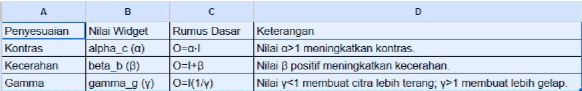



"Untuk Mengaktifkan CLAHE Tile dan Clip"
Dengan melihat fungsinya, ikuti langkah-langkah berikut ini:
-. Pastikan Contrast (α), Brightness (β), dan Gamma (γ) diatur ke nilai: (misalnya, 1.0, 0, 1.0) agar penyesuaian CLAHE lebih jelas.

-. Ubah widget Equalization dari "None" menjadi "Luma".

    -Sekarang, foto Anda sudah ditingkatkan kontrasnya melalui Histogram Equalization global pada saluran Luma (karena clahe_clip masih diatur ke nilai default 2.0 dan clahe_tile ke 8, yang merupakan default CLAHE).
- Ubah Nilai CLAHE:

    A. CLAHE clip: Coba atur ke 0.0 (untuk menonaktifkan clip dan melihat Equalization global standar pada Luma). Kemudian, naikkan nilainya (misalnya 5.0 atau 10.0) untuk melihat bagaimana kontras lokal ditingkatkan. Nilai yang lebih tinggi meningkatkan kontras.

    B. CLAHE tile: Coba atur ke 32 (untuk area tile yang lebih kecil, yang meningkatkan penyesuaian lokal dan detail). Kemudian, atur ke 2 (untuk area tile yang jauh lebih besar, mendekati Equalization global).

1. Pengaruh α (kontras) dan β (kecerahan) terhadap citra underexposed dan overexposed

- Kontras (α):
Nilai α berfungsi sebagai pengali pada intensitas piksel. Jika gambar terlalu gelap (underexposed), menaikkan nilai α (>1) bisa membantu memperlebar rentang intensitas sehingga bagian gelap terlihat lebih pekat dan bagian terang tampak lebih jelas — hasilnya kontras keseluruhan meningkat.
Namun, untuk gambar yang terlalu terang (overexposed), penggunaan α yang terlalu tinggi justru bisa menyebabkan clipping, yaitu ketika area terang kehilangan detail karena nilainya sudah mencapai batas maksimum (255).

- Kecerahan (β):
Sementara itu, β berperan sebagai penggeser nilai piksel. Pada gambar yang kurang pencahayaan, menaikkan β (misalnya +40 atau +50) bisa membantu mencerahkan seluruh bagian gambar. Sebaliknya, untuk gambar yang terlalu terang, menurunkan β (nilai negatif) dapat sedikit meredupkan hasilnya. Tapi perlu hati-hati, karena jika nilainya terlalu ekstrem, bisa menyebabkan detail di area gelap atau terang semakin hilang dan tidak bisa dikembalikan lagi.

2. Kapan sebaiknya menggunakan γ < 1 dan γ > 1?

- Gamma (γ < 1) – untuk mencerahkan gambar:
Nilai gamma di bawah 1, misalnya 0.5, biasanya digunakan saat gambar terlalu gelap (underexposed). Pengaturan ini akan membuat bagian bayangan dan area bernada tengah menjadi lebih terang tanpa membuat area terang jadi terlalu silau. Dengan kata lain, γ < 1 membantu menampilkan detail di area gelap yang sebelumnya tidak terlihat.

- Gamma (γ > 1) – untuk menggelapkan atau menambah kontras bagian gelap:
Sebaliknya, gamma dengan nilai di atas 1, misalnya 2.0, cocok diterapkan pada gambar yang terlalu terang (overexposed). Efeknya adalah mempergelap area terang dan menambah kedalaman pada warna-warna gelap, sehingga hasilnya tampak lebih seimbang dan memiliki kontras yang lebih kuat. Nilai γ > 1 juga sering dipakai untuk mengurangi efek cahaya berlebih (bloom) pada foto.


3. Perbandingan hasil Equalize Gray dan Equalize Luma (LAB)

- Equalize Gray (pada Grayscale):
Pada metode ini, gambar terlebih dahulu diubah menjadi format grayscale, kemudian dilakukan proses pemerataan histogram secara keseluruhan. Efeknya, kontras gambar meningkat cukup drastis karena distribusi intensitas piksel diratakan di seluruh rentang nilai. Namun, karena semua informasi warna dihilangkan, hasil akhirnya hanya berupa gambar hitam putih dengan kontras yang tinggi.

- Equalize Luma (pada channel L di LAB):
Sementara itu, metode Equalize Luma bekerja dengan mengubah gambar ke ruang warna LAB, lalu hanya melakukan equalization pada channel L (Luminance/Lightness), tanpa mengubah channel A dan B yang menyimpan informasi warna. Dengan cara ini, gambar tetap berwarna tetapi memiliki kecerahan dan kontras yang lebih seimbang. Pendekatan ini biasanya lebih baik untuk foto berwarna karena tidak menyebabkan perubahan warna yang tidak alami (color shift).

4. Mengapa CLAHE lebih stabil pada pencahayaan yang tidak merata?

    CLAHE (Contrast Limited Adaptive Histogram Equalization) bekerja dengan cara membagi gambar menjadi beberapa bagian kecil yang disebut tiles (dalam kode diwakili oleh clahe_tile). Setiap tile diproses secara terpisah, di mana histogramnya dihitung dan dilakukan pemerataan (equalization) secara lokal.

    Pada gambar yang memiliki pencahayaan tidak merata — misalnya, satu sisi tampak sangat terang sedangkan sisi lain cenderung gelap — metode equalization global biasanya kurang efektif, karena hasilnya sering didominasi oleh area terang atau gelap saja. Dengan pendekatan CLAHE, kontras diatur per bagian, sehingga area gelap bisa ditingkatkan tanpa harus mengorbankan area terang.

    Selain itu, fitur Contrast Limited (clahe_clip) berfungsi untuk membatasi peningkatan kontras agar tidak terlalu berlebihan. Mekanisme ini penting untuk mencegah munculnya noise di area yang seharusnya homogen, yang kadang bisa terjadi jika kontras lokal diperbesar terlalu kuat.

--Kesimpulan Akhir--

Secara keseluruhan, kode ini menyediakan seperangkat alat interaktif untuk memperbaiki kualitas visual sebuah gambar.

A. Kontras (α) dan Kecerahan (β) bekerja secara linier untuk menyesuaikan tingkat terang dan gelap pada keseluruhan gambar.

B. Gamma (γ) bersifat non-linier dan berguna untuk mengatur nada tengah, terutama pada foto yang terlalu gelap atau terlalu terang.

C. Equalize Luma (LAB) menawarkan cara peningkatan kontras yang lebih halus untuk gambar berwarna tanpa mengubah karakter warnanya.

D.Sedangkan CLAHE memperluas konsep ini dengan melakukan penyesuaian kontras secara lokal menggunakan tiles dan clip limit, menjadikannya lebih stabil dan efektif pada gambar dengan pencahayaan yang tidak merata atau kompleks.